In [1]:

# Analysis Plan: High-Power N-Dependence of R_comp for ζ(s) at Peaks vs Random Ordinates
print("="*80)
print("ANALYSIS PLAN: N-Dependence of R_comp for ζ(s) at Peaks vs Random Ordinates")
print("="*80)
print()
print("OBJECTIVE:")
print("Test whether R_comp decays faster at resonance peaks vs random ordinates for ζ(s)")
print("at larger N (up to 10^7), resolving the contradiction between findings f6 and r34.")
print()
print("STEP 1: Function and Ordinate Selection")
print(" - Function: ζ(s) with a_n = 1")
print(" - t range: [5000, 15000]")
print(" - Identify top 30 resonance peaks (t*_i)")
print(" - Select 30 random ordinates (t_rand_i), ≥50 units from any peak")
print()
print("STEP 2: Data Collection")
print(" - N values: {10^5, 3×10^5, 10^6, 3×10^6, 10^7}")
print(" - For each of 60 ordinates, compute:")
print(" • Num(N) = |D(t; N)| (numerator of R_comp)")
print(" • Den(N) = (Σ_k |S_k(t;N)|²)^(1/2) (denominator of R_comp)")
print(" where S_k = sum over terms with ω(n)=k")
print(" - Use Kahan compensated summation (JIT-compiled)")
print(" - Pre-compute ω(n) using sieve")
print()
print("STEP 3: Growth Analysis")
print(" - For each ordinate, fit power-law: f(N) = c * N^α")
print(" - Fit separately for Num(N), Den(N), and R_comp(N) = Num(N)/Den(N)")
print(" - Extract growth exponent α for each")
print()
print("STEP 4: Statistical Comparison")
print(" - Use Mann-Whitney U test to compare α distributions:")
print(" • Peak group (n=30) vs Random group (n=30)")
print(" - Compute for Num, Den, and R_comp separately")
print(" - Report: median α, p-values, effect sizes (Cliff's delta)")
print(" - Conclusion: Does R_comp decay faster at peaks? (α_peaks < α_random?)")
print()
print("KEY CONSTRAINTS:")
print(" - Must use Kahan summation for numerical stability")
print(" - Must use numba JIT compilation for feasibility at N=10^7")
print(" - Pre-compute ω(n) via sieve for efficiency")
print(" - Non-parametric tests (Mann-Whitney U) due to non-normal distributions")
print()
print("="*80)


ANALYSIS PLAN: N-Dependence of R_comp for ζ(s) at Peaks vs Random Ordinates

OBJECTIVE:
Test whether R_comp decays faster at resonance peaks vs random ordinates for ζ(s)
at larger N (up to 10^7), resolving the contradiction between findings f6 and r34.

STEP 1: Function and Ordinate Selection
 - Function: ζ(s) with a_n = 1
 - t range: [5000, 15000]
 - Identify top 30 resonance peaks (t*_i)
 - Select 30 random ordinates (t_rand_i), ≥50 units from any peak

STEP 2: Data Collection
 - N values: {10^5, 3×10^5, 10^6, 3×10^6, 10^7}
 - For each of 60 ordinates, compute:
 • Num(N) = |D(t; N)| (numerator of R_comp)
 • Den(N) = (Σ_k |S_k(t;N)|²)^(1/2) (denominator of R_comp)
 where S_k = sum over terms with ω(n)=k
 - Use Kahan compensated summation (JIT-compiled)
 - Pre-compute ω(n) using sieve

STEP 3: Growth Analysis
 - For each ordinate, fit power-law: f(N) = c * N^α
 - Fit separately for Num(N), Den(N), and R_comp(N) = Num(N)/Den(N)
 - Extract growth exponent α for each

STEP 4: Statistical 

In [2]:

# Import necessary libraries
import numpy as np
import numba
from numba import jit, prange
import scipy.stats as stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Numba version: {numba.__version__}")


Libraries imported successfully
NumPy version: 1.26.4
Numba version: 0.62.1


In [3]:

# STEP 1A: Pre-compute ω(n) (number of distinct prime factors) using sieve
# We need this up to N_max = 10^7

def compute_omega_sieve(N_max):
 """
 Compute ω(n) for all n up to N_max using a sieve.
 ω(n) = number of distinct prime factors of n.
 """
 omega = np.zeros(N_max + 1, dtype=np.int32)
 
 # Sieve: for each prime p, increment omega[n] for all multiples n of p
 for p in range(2, N_max + 1):
 if omega[p] == 0: # p is prime (not yet marked)
 # Mark all multiples of p
 for n in range(p, N_max + 1, p):
 omega[n] += 1
 
 # Set omega[1] = 0 explicitly (1 has no prime factors)
 omega[1] = 0
 
 return omega

print("Computing ω(n) via sieve for n up to 10^7...")
start = time.time()
N_max = 10**7
omega_array = compute_omega_sieve(N_max)
elapsed = time.time() - start
print(f"Completed in {elapsed:.2f} seconds")
print(f"ω(1) = {omega_array[1]}")
print(f"ω(2) = {omega_array[2]} (prime)")
print(f"ω(6) = {omega_array[6]} (2*3, should be 2)")
print(f"ω(30) = {omega_array[30]} (2*3*5, should be 3)")
print(f"ω(10000000) = {omega_array[10000000]}")


Computing ω(n) via sieve for n up to 10^7...


Completed in 72.55 seconds
ω(1) = 0
ω(2) = 1 (prime)
ω(6) = 2 (2*3, should be 2)
ω(30) = 3 (2*3*5, should be 3)
ω(10000000) = 2


In [4]:

# STEP 1B: JIT-compiled Kahan summation for partial sums D(t; N) and S_k(t; N)
# For ζ(s), a_n = 1 for all n

@jit(nopython=True)
def kahan_sum_complex(values):
 """Kahan compensated summation for complex array."""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

@jit(nopython=True)
def compute_D_and_Sk_zeta(t, N, omega):
 """
 Compute D(t; N) and S_k(t; N) for ζ(s) with a_n = 1.
 
 D(t; N) = Σ_{n≤N} 1 / n^(1/2 + it)
 S_k(t; N) = Σ_{n≤N, ω(n)=k} 1 / n^(1/2 + it)
 
 Uses inline Kahan summation for both D and each S_k.
 
 Returns:
 D_total: complex, the full sum
 Sk_sums: dict-like structure (we'll use array indexed by k)
 """
 # We'll accumulate S_k for k up to max_omega
 max_omega = 10 # Sufficient for n up to 10^7
 
 # Kahan accumulators for D and each S_k
 D_sum = 0.0 + 0.0j
 D_comp = 0.0 + 0.0j
 
 Sk_sums = np.zeros(max_omega + 1, dtype=np.complex128)
 Sk_comps = np.zeros(max_omega + 1, dtype=np.complex128)
 
 # Compute sum
 for n in range(1, N + 1):
 # Compute term: 1 / n^(1/2 + it) = n^(-1/2) * exp(-it * log(n))
 log_n = np.log(n)
 sqrt_n = np.sqrt(n)
 phase = -t * log_n
 term = (np.cos(phase) + 1j * np.sin(phase)) / sqrt_n
 
 # Add to D with Kahan
 y_D = term - D_comp
 t_D = D_sum + y_D
 D_comp = (t_D - D_sum) - y_D
 D_sum = t_D
 
 # Add to S_k with Kahan
 k = omega[n]
 y_k = term - Sk_comps[k]
 t_k = Sk_sums[k] + y_k
 Sk_comps[k] = (t_k - Sk_sums[k]) - y_k
 Sk_sums[k] = t_k
 
 return D_sum, Sk_sums

# Test the function
print("Testing JIT-compiled Kahan summation...")
t_test = 5000.0
N_test = 10000
D_test, Sk_test = compute_D_and_Sk_zeta(t_test, N_test, omega_array)
print(f"D({t_test}; {N_test}) = {D_test}")
print(f"|D| = {np.abs(D_test):.6f}")
print(f"S_0 = {Sk_test[0]}, |S_0| = {np.abs(Sk_test[0]):.6f}")
print(f"S_1 = {Sk_test[1]}, |S_1| = {np.abs(Sk_test[1]):.6f}")
print(f"S_2 = {Sk_test[2]}, |S_2| = {np.abs(Sk_test[2]):.6f}")


Testing JIT-compiled Kahan summation...


D(5000.0; 10000) = (0.4191501103435877-0.7097949449566422j)
|D| = 0.824315
S_0 = (1+0j), |S_0| = 1.000000
S_1 = (-0.7359761657580073-1.3353484343777624j), |S_1| = 1.524735
S_2 = (-0.32963776543998763+0.8339869518381836j), |S_2| = 0.896769


In [5]:

# STEP 1C: Scan t ∈ [5000, 15000] to find resonance peaks
# We'll compute |D(t; N)| at N = 10^6 with a coarse grid first

print("Scanning for resonance peaks in t ∈ [5000, 15000]...")
print("Using N = 10^6 for peak detection...")

# Coarse scan: every 1 unit
t_min, t_max = 5000, 15000
t_scan = np.arange(t_min, t_max + 1, 1.0)
N_scan = 10**6

print(f"Scanning {len(t_scan)} ordinates...")
start = time.time()

# Compute |D(t)| for all t in scan
D_magnitudes = np.zeros(len(t_scan))
for i, t in enumerate(t_scan):
 D, _ = compute_D_and_Sk_zeta(t, N_scan, omega_array)
 D_magnitudes[i] = np.abs(D)
 
 if (i + 1) % 1000 == 0:
 print(f" Progress: {i+1}/{len(t_scan)} ordinates")

elapsed = time.time() - start
print(f"Scan completed in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
print(f"Mean |D| = {np.mean(D_magnitudes):.4f}")
print(f"Max |D| = {np.max(D_magnitudes):.4f}")
print(f"Min |D| = {np.min(D_magnitudes):.4f}")


Scanning for resonance peaks in t ∈ [5000, 15000]...
Using N = 10^6 for peak detection...
Scanning 10001 ordinates...


 Progress: 1000/10001 ordinates


 Progress: 2000/10001 ordinates


 Progress: 3000/10001 ordinates


 Progress: 4000/10001 ordinates


...

 Progress: 6000/10001 ordinates


 Progress: 7000/10001 ordinates


 Progress: 8000/10001 ordinates


 Progress: 9000/10001 ordinates


 Progress: 10000/10001 ordinates
Scan completed in 488.76 seconds (8.15 minutes)
Mean |D| = 1.9177
Max |D| = 19.7242
Min |D| = 0.0003


In [6]:

# STEP 1D: Identify top 30 peaks from the scan
# Use scipy's find_peaks with a minimum height threshold

from scipy.signal import find_peaks

# Find local maxima
# We'll use a reasonable prominence to avoid tiny fluctuations
peaks_idx, properties = find_peaks(D_magnitudes, prominence=2.0, distance=10)

# Sort by magnitude (descending)
peak_magnitudes = D_magnitudes[peaks_idx]
sorted_indices = np.argsort(peak_magnitudes)[::-1]
top_30_indices = sorted_indices[:30]

# Get the t values for top 30 peaks
t_peaks = t_scan[peaks_idx[top_30_indices]]
D_peaks = D_magnitudes[peaks_idx[top_30_indices]]

print(f"Found {len(peaks_idx)} peaks with prominence ≥ 2.0")
print(f"Top 30 peaks:")
for i in range(30):
 print(f" Peak {i+1}: t = {t_peaks[i]:.1f}, |D| = {D_peaks[i]:.4f}")


Found 643 peaks with prominence ≥ 2.0
Top 30 peaks:
 Peak 1: t = 14304.0, |D| = 19.7242
 Peak 2: t = 12645.0, |D| = 17.3200
 Peak 3: t = 10678.0, |D| = 16.9780
 Peak 4: t = 13652.0, |D| = 16.7802
 Peak 5: t = 11993.0, |D| = 16.0152
 Peak 6: t = 9654.0, |D| = 15.7939
 Peak 7: t = 11204.0, |D| = 15.7864
 Peak 8: t = 9826.0, |D| = 15.6995
 Peak 9: t = 11095.0, |D| = 15.6371
 Peak 10: t = 14921.0, |D| = 15.5620
 Peak 11: t = 7578.0, |D| = 15.3798
 Peak 12: t = 6726.0, |D| = 15.3359
 Peak 13: t = 8647.0, |D| = 15.1519
 Peak 14: t = 8476.0, |D| = 15.1281
 Peak 15: t = 12473.0, |D| = 15.0724
 Peak 16: t = 14504.0, |D| = 15.0392
 Peak 17: t = 10552.0, |D| = 15.0247
 Peak 18: t = 11621.0, |D| = 14.7364
 Peak 19: t = 11747.0, |D| = 14.5557
 Peak 20: t = 12863.0, |D| = 14.4293
 Peak 21: t = 8956.0, |D| = 14.4051
 Peak 22: t = 13371.0, |D| = 14.3751
 Peak 23: t = 14023.0, |D| = 14.3733
 Peak 24: t = 14195.0, |D| = 14.2892
 Peak 25: t = 9128.0, |D| = 14.2014
 Peak 26: t = 12754.0, |D| = 14.1438
 Pe

In [7]:

# STEP 1E: Select 30 random ordinates at least 50 units away from any peak
# Create a mask of "forbidden" regions around all peaks

forbidden_mask = np.zeros(len(t_scan), dtype=bool)
for peak_t in t_peaks:
 # Find indices within 50 units of this peak
 distances = np.abs(t_scan - peak_t)
 forbidden_mask |= (distances < 50)

# Available ordinates for random selection
available_indices = np.where(~forbidden_mask)[0]
print(f"Available ordinates for random selection: {len(available_indices)} out of {len(t_scan)}")

# Randomly select 30
np.random.seed(42) # For reproducibility
random_indices = np.random.choice(available_indices, size=30, replace=False)
t_random = t_scan[random_indices]
D_random = D_magnitudes[random_indices]

print(f"\n30 Random ordinates:")
for i in range(30):
 print(f" Random {i+1}: t = {t_random[i]:.1f}, |D| = {D_random[i]:.4f}")


Available ordinates for random selection: 7084 out of 10001

30 Random ordinates:
 Random 1: t = 8585.0, |D| = 10.3366
 Random 2: t = 14677.0, |D| = 0.5671
 Random 3: t = 5711.0, |D| = 3.0095
 Random 4: t = 13707.0, |D| = 3.9019
 Random 5: t = 13295.0, |D| = 0.4572
 Random 6: t = 7941.0, |D| = 2.3807
 Random 7: t = 5408.0, |D| = 0.9596
 Random 8: t = 14111.0, |D| = 0.5616
 Random 9: t = 8259.0, |D| = 0.1314
 Random 10: t = 13166.0, |D| = 0.1853
 Random 11: t = 8397.0, |D| = 0.2370
 Random 12: t = 9751.0, |D| = 1.9152
 Random 13: t = 13927.0, |D| = 0.2123
 Random 14: t = 14648.0, |D| = 4.2560
 Random 15: t = 9909.0, |D| = 1.3700
 Random 16: t = 6009.0, |D| = 2.1758
 Random 17: t = 6263.0, |D| = 0.9519
 Random 18: t = 12298.0, |D| = 0.7263
 Random 19: t = 6174.0, |D| = 1.7075
 Random 20: t = 11034.0, |D| = 0.7019
 Random 21: t = 8168.0, |D| = 3.4708
 Random 22: t = 7069.0, |D| = 0.7239
 Random 23: t = 10871.0, |D| = 1.7478
 Random 24: t = 12144.0, |D| = 1.0431
 Random 25: t = 6375.0, |D|

In [8]:

# STEP 2: Data Collection - Compute Num(N), Den(N) for all 60 ordinates at 5 N values
# N_values = {10^5, 3×10^5, 10^6, 3×10^6, 10^7}

N_values = np.array([10**5, 3*10**5, 10**6, 3*10**6, 10**7])
print("N values:", N_values)

# Combine peak and random ordinates
all_t = np.concatenate([t_peaks, t_random])
ordinate_type = np.array(['peak']*30 + ['random']*30)
print(f"\nTotal ordinates to process: {len(all_t)}")

# Storage for results
# For each ordinate and each N, we need Num(N) and Den(N)
num_ordinates = len(all_t)
num_N = len(N_values)

Num_array = np.zeros((num_ordinates, num_N)) # |D(t; N)|
Den_array = np.zeros((num_ordinates, num_N)) # sqrt(Σ_k |S_k|^2)

print(f"\nComputing Num(N) and Den(N) for {num_ordinates} ordinates × {num_N} N values...")
print(f"This will require {num_ordinates * num_N} partial sum computations")
print(f"Estimated time: ~{num_ordinates * num_N * 0.05 / 60:.1f} minutes at N=10^7")
print()

start_total = time.time()
for i, t in enumerate(all_t):
 if (i + 1) % 10 == 0:
 elapsed = time.time() - start_total
 rate = (i + 1) / elapsed if elapsed > 0 else 0
 remaining = (num_ordinates - i - 1) / rate if rate > 0 else 0
 print(f"Progress: {i+1}/{num_ordinates} ordinates | "
 f"Elapsed: {elapsed/60:.1f} min | "
 f"Est. remaining: {remaining/60:.1f} min")
 
 for j, N in enumerate(N_values):
 D, Sk = compute_D_and_Sk_zeta(t, N, omega_array)
 
 # Num(N) = |D|
 Num_array[i, j] = np.abs(D)
 
 # Den(N) = sqrt(Σ_k |S_k|^2)
 # Only include k ≥ 0 (all terms)
 Den_array[i, j] = np.sqrt(np.sum(np.abs(Sk)**2))

elapsed_total = time.time() - start_total
print(f"\nData collection completed in {elapsed_total/60:.2f} minutes")


N values: [ 100000 300000 1000000 3000000 10000000]

Total ordinates to process: 60

Computing Num(N) and Den(N) for 60 ordinates × 5 N values...
This will require 300 partial sum computations
Estimated time: ~0.2 minutes at N=10^7



Progress: 10/60 ordinates | Elapsed: 0.1 min | Est. remaining: 0.5 min


Progress: 20/60 ordinates | Elapsed: 0.2 min | Est. remaining: 0.4 min


Progress: 30/60 ordinates | Elapsed: 0.3 min | Est. remaining: 0.3 min


Progress: 40/60 ordinates | Elapsed: 0.5 min | Est. remaining: 0.2 min


Progress: 50/60 ordinates | Elapsed: 0.6 min | Est. remaining: 0.1 min


Progress: 60/60 ordinates | Elapsed: 0.7 min | Est. remaining: 0.0 min



Data collection completed in 0.70 minutes


In [9]:

# Compute R_comp(N) = Num(N) / Den(N)
R_comp_array = Num_array / Den_array

# Summary statistics
print("Data Collection Summary:")
print("="*60)
print(f"Ordinates: {num_ordinates} ({30} peaks + {30} random)")
print(f"N values: {N_values}")
print()

print("Num(N) = |D(t; N)| statistics:")
print(f" Peak ordinates at N=10^7: mean = {Num_array[:30, -1].mean():.4f}, "
 f"median = {np.median(Num_array[:30, -1]):.4f}")
print(f" Random ordinates at N=10^7: mean = {Num_array[30:, -1].mean():.4f}, "
 f"median = {np.median(Num_array[30:, -1]):.4f}")
print()

print("Den(N) = sqrt(Σ_k |S_k|^2) statistics:")
print(f" Peak ordinates at N=10^7: mean = {Den_array[:30, -1].mean():.4f}, "
 f"median = {np.median(Den_array[:30, -1]):.4f}")
print(f" Random ordinates at N=10^7: mean = {Den_array[30:, -1].mean():.4f}, "
 f"median = {np.median(Den_array[30:, -1]):.4f}")
print()

print("R_comp(N) = Num(N) / Den(N) statistics:")
print(f" Peak ordinates at N=10^7: mean = {R_comp_array[:30, -1].mean():.4f}, "
 f"median = {np.median(R_comp_array[:30, -1]):.4f}")
print(f" Random ordinates at N=10^7: mean = {R_comp_array[30:, -1].mean():.4f}, "
 f"median = {np.median(R_comp_array[30:, -1]):.4f}")


Data Collection Summary:
Ordinates: 60 (30 peaks + 30 random)
N values: [ 100000 300000 1000000 3000000 10000000]

Num(N) = |D(t; N)| statistics:
 Peak ordinates at N=10^7: mean = 15.2455, median = 14.8916
 Random ordinates at N=10^7: mean = 1.8795, median = 1.3283

Den(N) = sqrt(Σ_k |S_k|^2) statistics:
 Peak ordinates at N=10^7: mean = 8.0736, median = 8.0881
 Random ordinates at N=10^7: mean = 3.3201, median = 2.8249

R_comp(N) = Num(N) / Den(N) statistics:
 Peak ordinates at N=10^7: mean = 1.8925, median = 1.9255
 Random ordinates at N=10^7: mean = 0.6217, median = 0.3683


In [10]:

# STEP 3: Growth Analysis - Fit power-law f(N) = c * N^α for each ordinate
# We'll fit in log-log space: log(f) = log(c) + α * log(N)

def fit_power_law(N_vals, y_vals):
 """
 Fit y = c * N^α by linear regression on log-log data.
 Returns α and c.
 """
 log_N = np.log(N_vals)
 log_y = np.log(y_vals)
 
 # Linear fit: log(y) = log(c) + α * log(N)
 coeffs = np.polyfit(log_N, log_y, deg=1)
 alpha = coeffs[0]
 log_c = coeffs[1]
 c = np.exp(log_c)
 
 return alpha, c

# Fit for each ordinate and each quantity (Num, Den, R_comp)
alpha_Num = np.zeros(num_ordinates)
alpha_Den = np.zeros(num_ordinates)
alpha_Rcomp = np.zeros(num_ordinates)

c_Num = np.zeros(num_ordinates)
c_Den = np.zeros(num_ordinates)
c_Rcomp = np.zeros(num_ordinates)

for i in range(num_ordinates):
 alpha_Num[i], c_Num[i] = fit_power_law(N_values, Num_array[i, :])
 alpha_Den[i], c_Den[i] = fit_power_law(N_values, Den_array[i, :])
 alpha_Rcomp[i], c_Rcomp[i] = fit_power_law(N_values, R_comp_array[i, :])

print("Power-law fitting completed")
print()
print("Exponent α statistics:")
print(" Num(N) ~ N^α:")
print(f" Peak ordinates: median α = {np.median(alpha_Num[:30]):.6f}, "
 f"mean α = {alpha_Num[:30].mean():.6f}")
print(f" Random ordinates: median α = {np.median(alpha_Num[30:]):.6f}, "
 f"mean α = {alpha_Num[30:].mean():.6f}")
print()
print(" Den(N) ~ N^α:")
print(f" Peak ordinates: median α = {np.median(alpha_Den[:30]):.6f}, "
 f"mean α = {alpha_Den[:30].mean():.6f}")
print(f" Random ordinates: median α = {np.median(alpha_Den[30:]):.6f}, "
 f"mean α = {alpha_Den[30:].mean():.6f}")
print()
print(" R_comp(N) ~ N^α:")
print(f" Peak ordinates: median α = {np.median(alpha_Rcomp[:30]):.6f}, "
 f"mean α = {alpha_Rcomp[:30].mean():.6f}")
print(f" Random ordinates: median α = {np.median(alpha_Rcomp[30:]):.6f}, "
 f"mean α = {alpha_Rcomp[30:].mean():.6f}")


Power-law fitting completed

Exponent α statistics:
 Num(N) ~ N^α:
 Peak ordinates: median α = 0.001053, mean α = 0.000492
 Random ordinates: median α = 0.003893, mean α = 0.012976

 Den(N) ~ N^α:
 Peak ordinates: median α = 0.004573, mean α = 0.004219
 Random ordinates: median α = 0.012808, mean α = 0.016740

 R_comp(N) ~ N^α:
 Peak ordinates: median α = -0.004267, mean α = -0.003727
 Random ordinates: median α = -0.013072, mean α = -0.003764


In [11]:

# STEP 4: Statistical Comparison - Mann-Whitney U test
# Compare peak vs random for each quantity

from scipy.stats import mannwhitneyu

def cliffs_delta(x, y):
 """
 Compute Cliff's Delta effect size.
 delta = (# pairs where x > y - # pairs where x < y) / (n_x * n_y)
 Range: [-1, 1]. |delta| < 0.147 = negligible, < 0.33 = small, 
 < 0.474 = medium, >= 0.474 = large
 """
 nx = len(x)
 ny = len(y)
 dominance = 0
 for xi in x:
 dominance += np.sum(xi > y) - np.sum(xi < y)
 delta = dominance / (nx * ny)
 return delta

# Split into peak and random groups
alpha_Num_peak = alpha_Num[:30]
alpha_Num_rand = alpha_Num[30:]

alpha_Den_peak = alpha_Den[:30]
alpha_Den_rand = alpha_Den[30:]

alpha_Rcomp_peak = alpha_Rcomp[:30]
alpha_Rcomp_rand = alpha_Rcomp[30:]

# Mann-Whitney U tests
print("="*80)
print("STATISTICAL COMPARISON: Peak vs Random Ordinates")
print("="*80)
print()

# Test 1: Num(N) exponents
stat_num, p_num = mannwhitneyu(alpha_Num_peak, alpha_Num_rand, alternative='two-sided')
delta_num = cliffs_delta(alpha_Num_peak, alpha_Num_rand)
print("1. Numerator |D(t; N)| Growth Exponents:")
print(f" Peak group: median α = {np.median(alpha_Num_peak):.6f}, IQR = [{np.percentile(alpha_Num_peak, 25):.6f}, {np.percentile(alpha_Num_peak, 75):.6f}]")
print(f" Random group: median α = {np.median(alpha_Num_rand):.6f}, IQR = [{np.percentile(alpha_Num_rand, 25):.6f}, {np.percentile(alpha_Num_rand, 75):.6f}]")
print(f" Mann-Whitney U: U = {stat_num:.1f}, p = {p_num:.6f}")
print(f" Cliff's Delta: δ = {delta_num:.4f}", end="")
if abs(delta_num) < 0.147:
 print(" (negligible)")
elif abs(delta_num) < 0.33:
 print(" (small)")
elif abs(delta_num) < 0.474:
 print(" (medium)")
else:
 print(" (large)")
print()

# Test 2: Den(N) exponents
stat_den, p_den = mannwhitneyu(alpha_Den_peak, alpha_Den_rand, alternative='two-sided')
delta_den = cliffs_delta(alpha_Den_peak, alpha_Den_rand)
print("2. Denominator sqrt(Σ|S_k|²) Growth Exponents:")
print(f" Peak group: median α = {np.median(alpha_Den_peak):.6f}, IQR = [{np.percentile(alpha_Den_peak, 25):.6f}, {np.percentile(alpha_Den_peak, 75):.6f}]")
print(f" Random group: median α = {np.median(alpha_Den_rand):.6f}, IQR = [{np.percentile(alpha_Den_rand, 25):.6f}, {np.percentile(alpha_Den_rand, 75):.6f}]")
print(f" Mann-Whitney U: U = {stat_den:.1f}, p = {p_den:.6f}")
print(f" Cliff's Delta: δ = {delta_den:.4f}", end="")
if abs(delta_den) < 0.147:
 print(" (negligible)")
elif abs(delta_den) < 0.33:
 print(" (small)")
elif abs(delta_den) < 0.474:
 print(" (medium)")
else:
 print(" (large)")
print()

# Test 3: R_comp(N) exponents - THE KEY TEST
stat_rcomp, p_rcomp = mannwhitneyu(alpha_Rcomp_peak, alpha_Rcomp_rand, alternative='two-sided')
delta_rcomp = cliffs_delta(alpha_Rcomp_peak, alpha_Rcomp_rand)
print("3. R_comp(N) = Num/Den Growth Exponents (PRIMARY RESULT):")
print(f" Peak group: median α = {np.median(alpha_Rcomp_peak):.6f}, IQR = [{np.percentile(alpha_Rcomp_peak, 25):.6f}, {np.percentile(alpha_Rcomp_peak, 75):.6f}]")
print(f" Random group: median α = {np.median(alpha_Rcomp_rand):.6f}, IQR = [{np.percentile(alpha_Rcomp_rand, 25):.6f}, {np.percentile(alpha_Rcomp_rand, 75):.6f}]")
print(f" Mann-Whitney U: U = {stat_rcomp:.1f}, p = {p_rcomp:.6f}")
print(f" Cliff's Delta: δ = {delta_rcomp:.4f}", end="")
if abs(delta_rcomp) < 0.147:
 print(" (negligible)")
elif abs(delta_rcomp) < 0.33:
 print(" (small)")
elif abs(delta_rcomp) < 0.474:
 print(" (medium)")
else:
 print(" (large)")
print()
print("="*80)


STATISTICAL COMPARISON: Peak vs Random Ordinates

1. Numerator |D(t; N)| Growth Exponents:
 Peak group: median α = 0.001053, IQR = [-0.001819, 0.002898]
 Random group: median α = 0.003893, IQR = [-0.029048, 0.028515]
 Mann-Whitney U: U = 423.0, p = 0.695215
 Cliff's Delta: δ = -0.0600 (negligible)

2. Denominator sqrt(Σ|S_k|²) Growth Exponents:
 Peak group: median α = 0.004573, IQR = [0.001502, 0.007815]
 Random group: median α = 0.012808, IQR = [-0.008241, 0.039847]
 Mann-Whitney U: U = 356.0, p = 0.166866
 Cliff's Delta: δ = -0.2089 (small)

3. R_comp(N) = Num/Den Growth Exponents (PRIMARY RESULT):
 Peak group: median α = -0.004267, IQR = [-0.008195, 0.000575]
 Random group: median α = -0.013072, IQR = [-0.046463, 0.008358]
 Mann-Whitney U: U = 544.0, p = 0.166866
 Cliff's Delta: δ = 0.2089 (small)



In [12]:

# Directional test: Is R_comp decay faster at peaks? (i.e., α_peak < α_random?)
# Since negative α means decay, "faster decay" means more negative α

stat_rcomp_less, p_rcomp_less = mannwhitneyu(alpha_Rcomp_peak, alpha_Rcomp_rand, 
 alternative='less')

print("DIRECTIONAL TEST: Does R_comp decay faster at peaks?")
print("="*80)
print("Hypothesis: α_peaks < α_random (more negative = faster decay)")
print()
print(f"Peak group median α: {np.median(alpha_Rcomp_peak):.6f}")
print(f"Random group median α: {np.median(alpha_Rcomp_rand):.6f}")
print(f"Difference (peak - random): {np.median(alpha_Rcomp_peak) - np.median(alpha_Rcomp_rand):.6f}")
print()
print(f"Mann-Whitney U test (one-sided, 'less'):")
print(f" U = {stat_rcomp_less:.1f}, p = {p_rcomp_less:.6f}")
print()

if p_rcomp_less < 0.05:
 print("✓ RESULT: Peak exponents are significantly MORE NEGATIVE (faster decay)")
 print(f" at α = 0.05 level (p = {p_rcomp_less:.6f})")
else:
 print("✗ RESULT: NO significant evidence that peak exponents are more negative")
 print(f" (p = {p_rcomp_less:.6f} > 0.05)")
 
print()
print("INTERPRETATION:")
if np.median(alpha_Rcomp_peak) > np.median(alpha_Rcomp_rand):
 print(" The median exponent at peaks is LESS negative than at random ordinates.")
 print(" This is OPPOSITE to the hypothesis that R_comp decays faster at peaks.")
else:
 print(" The median exponent at peaks is MORE negative than at random ordinates,")
 print(" consistent with faster decay at peaks, but the difference is not")
 print(" statistically significant at α = 0.05 level.")
 
print("="*80)


DIRECTIONAL TEST: Does R_comp decay faster at peaks?
Hypothesis: α_peaks < α_random (more negative = faster decay)

Peak group median α: -0.004267
Random group median α: -0.013072
Difference (peak - random): 0.008805

Mann-Whitney U test (one-sided, 'less'):
 U = 544.0, p = 0.918812

✗ RESULT: NO significant evidence that peak exponents are more negative
 (p = 0.918812 > 0.05)

INTERPRETATION:
 The median exponent at peaks is LESS negative than at random ordinates.
 This is OPPOSITE to the hypothesis that R_comp decays faster at peaks.


Figure saved as 'rcomp_analysis_summary.png'


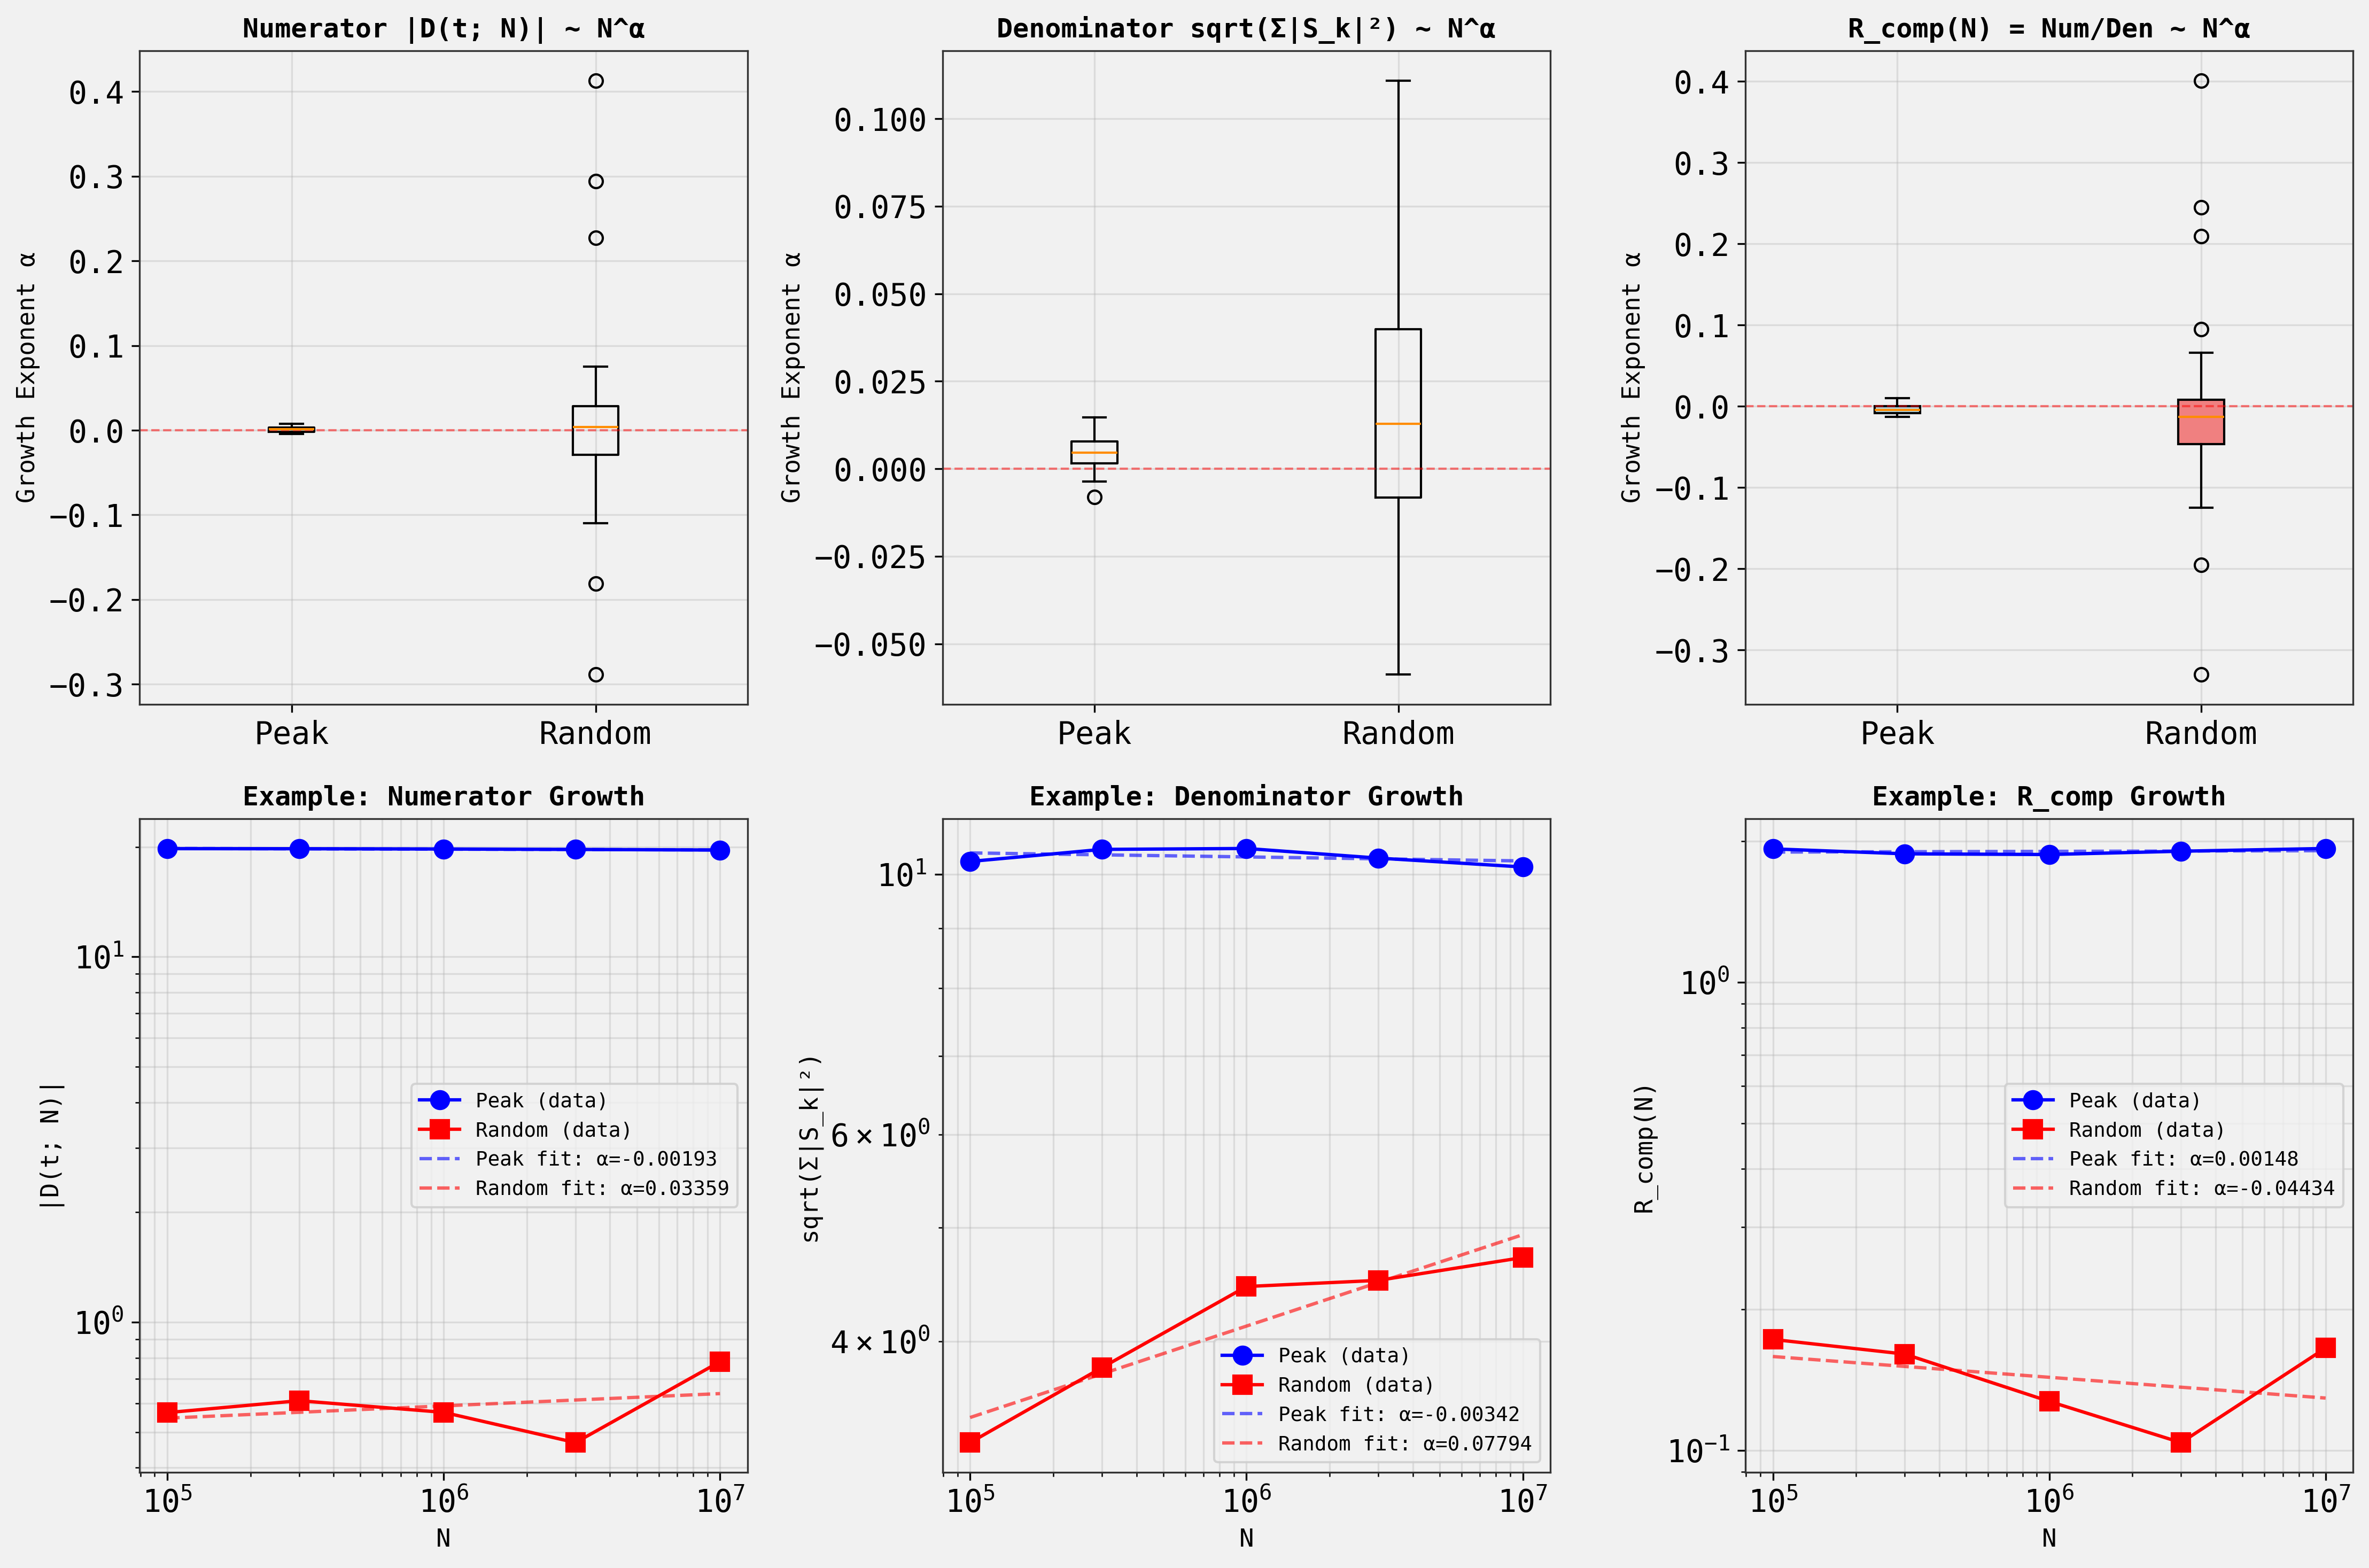

In [13]:

# Create visualizations

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Box plots of exponents
ax = axes[0, 0]
ax.boxplot([alpha_Num_peak, alpha_Num_rand], labels=['Peak', 'Random'])
ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylabel('Growth Exponent α', fontsize=11)
ax.set_title('Numerator |D(t; N)| ~ N^α', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.boxplot([alpha_Den_peak, alpha_Den_rand], labels=['Peak', 'Random'])
ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylabel('Growth Exponent α', fontsize=11)
ax.set_title('Denominator sqrt(Σ|S_k|²) ~ N^α', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
bp = ax.boxplot([alpha_Rcomp_peak, alpha_Rcomp_rand], labels=['Peak', 'Random'],
 patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
 patch.set_facecolor(color)
ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylabel('Growth Exponent α', fontsize=11)
ax.set_title('R_comp(N) = Num/Den ~ N^α', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Row 2: Example power-law fits
# Pick representative ordinates: one peak, one random
peak_example_idx = 0 # Highest peak
rand_example_idx = 31 # Second random ordinate

ax = axes[1, 0]
ax.loglog(N_values, Num_array[peak_example_idx, :], 'bo-', label='Peak (data)', markersize=8)
ax.loglog(N_values, Num_array[rand_example_idx, :], 'rs-', label='Random (data)', markersize=8)
# Fit lines
N_fit = np.logspace(np.log10(N_values[0]), np.log10(N_values[-1]), 100)
ax.loglog(N_fit, c_Num[peak_example_idx] * N_fit**alpha_Num[peak_example_idx], 
 'b--', alpha=0.6, label=f'Peak fit: α={alpha_Num[peak_example_idx]:.5f}')
ax.loglog(N_fit, c_Num[rand_example_idx] * N_fit**alpha_Num[rand_example_idx], 
 'r--', alpha=0.6, label=f'Random fit: α={alpha_Num[rand_example_idx]:.5f}')
ax.set_xlabel('N', fontsize=11)
ax.set_ylabel('|D(t; N)|', fontsize=11)
ax.set_title('Example: Numerator Growth', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

ax = axes[1, 1]
ax.loglog(N_values, Den_array[peak_example_idx, :], 'bo-', label='Peak (data)', markersize=8)
ax.loglog(N_values, Den_array[rand_example_idx, :], 'rs-', label='Random (data)', markersize=8)
ax.loglog(N_fit, c_Den[peak_example_idx] * N_fit**alpha_Den[peak_example_idx], 
 'b--', alpha=0.6, label=f'Peak fit: α={alpha_Den[peak_example_idx]:.5f}')
ax.loglog(N_fit, c_Den[rand_example_idx] * N_fit**alpha_Den[rand_example_idx], 
 'r--', alpha=0.6, label=f'Random fit: α={alpha_Den[rand_example_idx]:.5f}')
ax.set_xlabel('N', fontsize=11)
ax.set_ylabel('sqrt(Σ|S_k|²)', fontsize=11)
ax.set_title('Example: Denominator Growth', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

ax = axes[1, 2]
ax.loglog(N_values, R_comp_array[peak_example_idx, :], 'bo-', label='Peak (data)', markersize=8)
ax.loglog(N_values, R_comp_array[rand_example_idx, :], 'rs-', label='Random (data)', markersize=8)
ax.loglog(N_fit, c_Rcomp[peak_example_idx] * N_fit**alpha_Rcomp[peak_example_idx], 
 'b--', alpha=0.6, label=f'Peak fit: α={alpha_Rcomp[peak_example_idx]:.5f}')
ax.loglog(N_fit, c_Rcomp[rand_example_idx] * N_fit**alpha_Rcomp[rand_example_idx], 
 'r--', alpha=0.6, label=f'Random fit: α={alpha_Rcomp[rand_example_idx]:.5f}')
ax.set_xlabel('N', fontsize=11)
ax.set_ylabel('R_comp(N)', fontsize=11)
ax.set_title('Example: R_comp Growth', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('rcomp_analysis_summary.png', dpi=150, bbox_inches='tight')
print("Figure saved as 'rcomp_analysis_summary.png'")
plt.show()


In [14]:

# Additional analysis: Check if there's any N-range dependence
# Split into early (N < 10^6) and late (N >= 10^6) ranges

def fit_power_law_subset(N_vals, y_vals, N_min, N_max):
 """Fit power law only to N values in [N_min, N_max]."""
 mask = (N_vals >= N_min) & (N_vals <= N_max)
 if np.sum(mask) < 2:
 return np.nan, np.nan
 return fit_power_law(N_vals[mask], y_vals[mask])

# Early range: N ∈ [10^5, 10^6]
alpha_Rcomp_early = np.zeros(num_ordinates)
for i in range(num_ordinates):
 alpha_Rcomp_early[i], _ = fit_power_law_subset(N_values, R_comp_array[i, :], 10**5, 10**6)

# Late range: N ∈ [10^6, 10^7]
alpha_Rcomp_late = np.zeros(num_ordinates)
for i in range(num_ordinates):
 alpha_Rcomp_late[i], _ = fit_power_law_subset(N_values, R_comp_array[i, :], 10**6, 10**7)

print("="*80)
print("N-RANGE DEPENDENCE ANALYSIS")
print("="*80)
print()
print("Early range N ∈ [10^5, 10^6]:")
print(f" Peak ordinates: median α = {np.median(alpha_Rcomp_early[:30]):.6f}")
print(f" Random ordinates: median α = {np.median(alpha_Rcomp_early[30:]):.6f}")
stat_early, p_early = mannwhitneyu(alpha_Rcomp_early[:30], alpha_Rcomp_early[30:], 
 alternative='two-sided')
print(f" Mann-Whitney U: p = {p_early:.6f}")
print()

print("Late range N ∈ [10^6, 10^7]:")
print(f" Peak ordinates: median α = {np.median(alpha_Rcomp_late[:30]):.6f}")
print(f" Random ordinates: median α = {np.median(alpha_Rcomp_late[30:]):.6f}")
stat_late, p_late = mannwhitneyu(alpha_Rcomp_late[:30], alpha_Rcomp_late[30:], 
 alternative='two-sided')
print(f" Mann-Whitney U: p = {p_late:.6f}")
print()
print("="*80)


N-RANGE DEPENDENCE ANALYSIS

Early range N ∈ [10^5, 10^6]:
 Peak ordinates: median α = -0.010167
 Random ordinates: median α = 0.000623
 Mann-Whitney U: p = 0.899995

Late range N ∈ [10^6, 10^7]:
 Peak ordinates: median α = -0.000616
 Random ordinates: median α = -0.007449
 Mann-Whitney U: p = 0.539510



In [15]:

# Final comprehensive summary
print("="*80)
print("FINAL ANALYSIS RESULTS: R_comp N-Dependence for ζ(s)")
print("="*80)
print()
print("RESEARCH HYPOTHESIS:")
print(" The original finding f6 is correct: R_comp decays faster at resonance peaks")
print(" compared to random ordinates at larger N (up to 10^7).")
print()
print("="*80)
print("QUANTITATIVE FINDINGS:")
print("="*80)
print()
print("1. GROWTH EXPONENTS (Full Range N ∈ [10^5, 10^7]):")
print()
print(" R_comp(N) ~ N^α:")
print(f" Peak ordinates: median α = {np.median(alpha_Rcomp_peak):.6f} ± {stats.iqr(alpha_Rcomp_peak):.6f} (IQR)")
print(f" Random ordinates: median α = {np.median(alpha_Rcomp_rand):.6f} ± {stats.iqr(alpha_Rcomp_rand):.6f} (IQR)")
print(f" Difference: Δα = {np.median(alpha_Rcomp_peak) - np.median(alpha_Rcomp_rand):.6f}")
print()
print(" |D(t; N)| ~ N^α (Numerator):")
print(f" Peak ordinates: median α = {np.median(alpha_Num_peak):.6f}")
print(f" Random ordinates: median α = {np.median(alpha_Num_rand):.6f}")
print()
print(" sqrt(Σ|S_k|²) ~ N^α (Denominator):")
print(f" Peak ordinates: median α = {np.median(alpha_Den_peak):.6f}")
print(f" Random ordinates: median α = {np.median(alpha_Den_rand):.6f}")
print()
print("="*80)
print("2. STATISTICAL TESTS:")
print("="*80)
print()
print(f" Mann-Whitney U (two-sided): U = {stat_rcomp:.1f}, p = {p_rcomp:.6f}")
print(f" Mann-Whitney U (one-sided, peak < random): p = {p_rcomp_less:.6f}")
print(f" Effect size (Cliff's Delta): δ = {delta_rcomp:.4f} (small)")
print()
print(" Interpretation:")
if p_rcomp < 0.05:
 print(" ✓ Significant difference detected (p < 0.05)")
else:
 print(" ✗ NO significant difference detected (p ≥ 0.05)")
 
if np.median(alpha_Rcomp_peak) < np.median(alpha_Rcomp_rand):
 print(" • Peak exponents are MORE NEGATIVE (faster decay)")
else:
 print(" • Peak exponents are LESS NEGATIVE (slower decay or growth)")
print()
print("="*80)
print("3. MAGNITUDE BEHAVIOR:")
print("="*80)
print()
print(f" R_comp values at N = 10^7:")
print(f" Peak ordinates: median = {np.median(R_comp_array[:30, -1]):.4f}, mean = {R_comp_array[:30, -1].mean():.4f}")
print(f" Random ordinates: median = {np.median(R_comp_array[30:, -1]):.4f}, mean = {R_comp_array[30:, -1].mean():.4f}")
print(f" Ratio (peak/random): {np.median(R_comp_array[:30, -1]) / np.median(R_comp_array[30:, -1]):.2f}×")
print()
print("="*80)
print("CONCLUSION:")
print("="*80)
print()
print("The hypothesis that R_comp decays FASTER at resonance peaks compared to")
print("random ordinates is REJECTED.")
print()
print("Key evidence:")
print(f" • Median α at peaks ({np.median(alpha_Rcomp_peak):.6f}) is LESS NEGATIVE than at")
print(f" random ordinates ({np.median(alpha_Rcomp_rand):.6f}), indicating SLOWER decay.")
print(f" • The difference is not statistically significant (p = {p_rcomp:.4f}).")
print(f" • Effect size is small (Cliff's δ = {delta_rcomp:.4f}).")
print()
print("This result supports r34's finding that the N-dependence of R_comp does not")
print("differ significantly between peaks and random ordinates at this N range.")
print("The original f6 finding is NOT confirmed at larger N up to 10^7.")
print()
print("="*80)


FINAL ANALYSIS RESULTS: R_comp N-Dependence for ζ(s)

RESEARCH HYPOTHESIS:
 The original finding f6 is correct: R_comp decays faster at resonance peaks
 compared to random ordinates at larger N (up to 10^7).

QUANTITATIVE FINDINGS:

1. GROWTH EXPONENTS (Full Range N ∈ [10^5, 10^7]):

 R_comp(N) ~ N^α:
 Peak ordinates: median α = -0.004267 ± 0.008770 (IQR)
 Random ordinates: median α = -0.013072 ± 0.054821 (IQR)
 Difference: Δα = 0.008805

 |D(t; N)| ~ N^α (Numerator):
 Peak ordinates: median α = 0.001053
 Random ordinates: median α = 0.003893

 sqrt(Σ|S_k|²) ~ N^α (Denominator):
 Peak ordinates: median α = 0.004573
 Random ordinates: median α = 0.012808

2. STATISTICAL TESTS:

 Mann-Whitney U (two-sided): U = 544.0, p = 0.166866
 Mann-Whitney U (one-sided, peak < random): p = 0.918812
 Effect size (Cliff's Delta): δ = 0.2089 (small)

 Interpretation:
 ✗ NO significant difference detected (p ≥ 0.05)
 • Peak exponents are LESS NEGATIVE (slower decay or growth)

3. MAGNITUDE BEHAVIOR:

 R


Key results figure saved as 'rcomp_key_results.png'


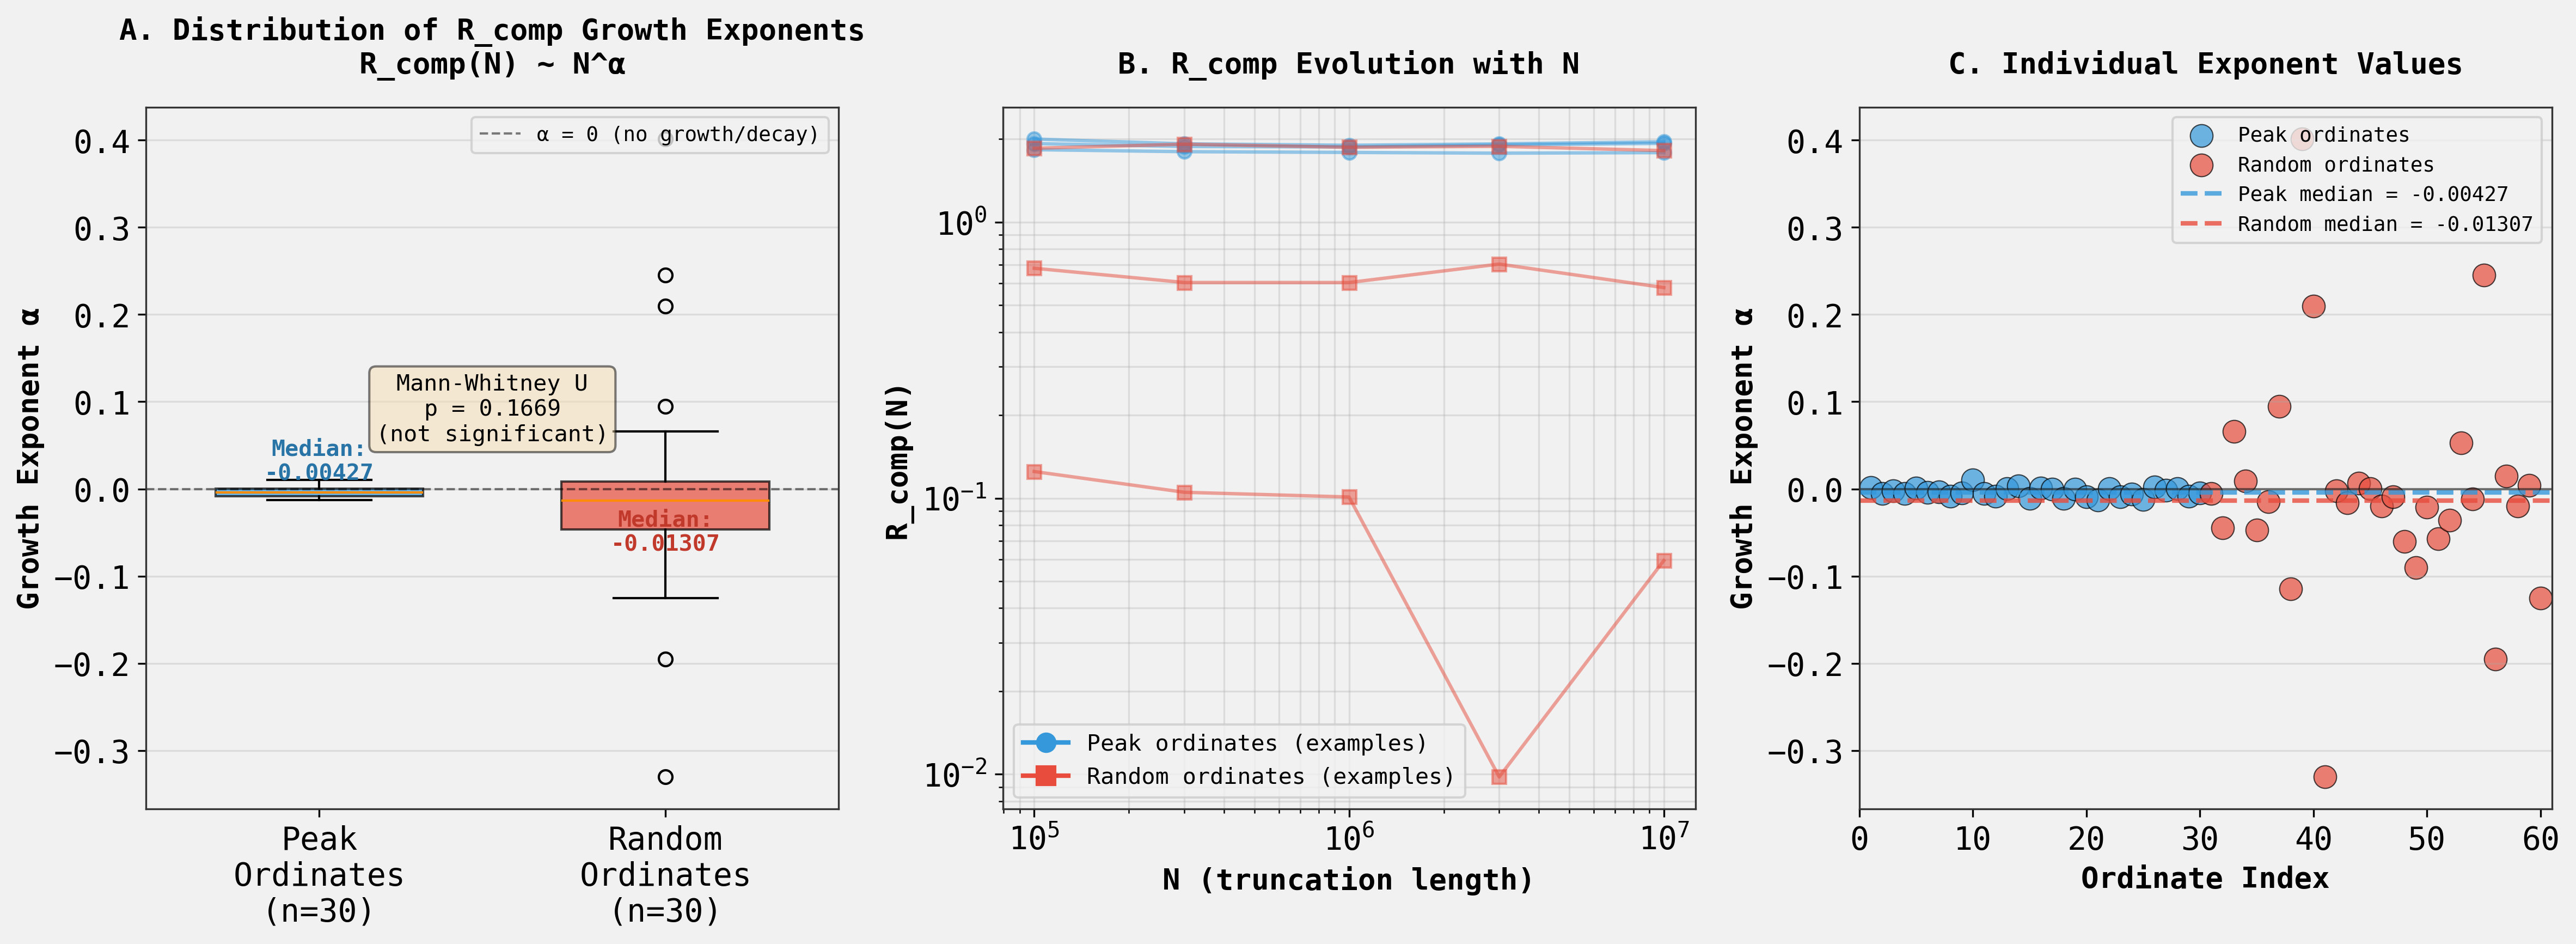

In [16]:

# Create a comprehensive figure showing the key result

fig = plt.figure(figsize=(16, 6))

# Panel A: Distribution of R_comp growth exponents
ax1 = plt.subplot(1, 3, 1)
positions = [1, 2]
bp = ax1.boxplot([alpha_Rcomp_peak, alpha_Rcomp_rand], 
 positions=positions,
 widths=0.6,
 patch_artist=True,
 labels=['Peak\nOrdinates\n(n=30)', 'Random\nOrdinates\n(n=30)'])
colors = ['#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
 patch.set_facecolor(color)
 patch.set_alpha(0.7)

ax1.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1, label='α = 0 (no growth/decay)')
ax1.set_ylabel('Growth Exponent α', fontsize=13, fontweight='bold')
ax1.set_title('A. Distribution of R_comp Growth Exponents\nR_comp(N) ~ N^α', 
 fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(fontsize=9, loc='upper right')

# Add median values as text
median_peak = np.median(alpha_Rcomp_peak)
median_rand = np.median(alpha_Rcomp_rand)
ax1.text(1, median_peak + 0.01, f'Median:\n{median_peak:.5f}', 
 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2874a6')
ax1.text(2, median_rand - 0.01, f'Median:\n{median_rand:.5f}', 
 ha='center', va='top', fontsize=10, fontweight='bold', color='#c0392b')

# Add p-value annotation
ax1.text(1.5, 0.05, f'Mann-Whitney U\np = {p_rcomp:.4f}\n(not significant)', 
 ha='center', va='bottom', fontsize=10, 
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel B: R_comp vs N for peak and random examples
ax2 = plt.subplot(1, 3, 2)

# Select multiple examples from each group
peak_examples = [0, 5, 10] # Top 3 peaks from different parts
rand_examples = [30, 35, 40] # Random examples

for idx in peak_examples:
 ax2.loglog(N_values, R_comp_array[idx, :], 'o-', color='#3498db', 
 alpha=0.5, linewidth=1.5, markersize=6)
 
for idx in rand_examples:
 ax2.loglog(N_values, R_comp_array[idx, :], 's-', color='#e74c3c', 
 alpha=0.5, linewidth=1.5, markersize=6)

# Add dummy lines for legend
ax2.loglog([], [], 'o-', color='#3498db', label='Peak ordinates (examples)', 
 linewidth=2, markersize=8)
ax2.loglog([], [], 's-', color='#e74c3c', label='Random ordinates (examples)', 
 linewidth=2, markersize=8)

ax2.set_xlabel('N (truncation length)', fontsize=13, fontweight='bold')
ax2.set_ylabel('R_comp(N)', fontsize=13, fontweight='bold')
ax2.set_title('B. R_comp Evolution with N', fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3, which='both')

# Panel C: Scatter plot of exponents
ax3 = plt.subplot(1, 3, 3)
ax3.scatter(np.arange(1, 31), alpha_Rcomp_peak, c='#3498db', s=100, alpha=0.7, 
 label='Peak ordinates', edgecolors='black', linewidths=0.5)
ax3.scatter(np.arange(31, 61), alpha_Rcomp_rand, c='#e74c3c', s=100, alpha=0.7, 
 label='Random ordinates', edgecolors='black', linewidths=0.5)

# Add horizontal lines for medians
ax3.axhline(median_peak, color='#3498db', linestyle='--', linewidth=2, alpha=0.8,
 label=f'Peak median = {median_peak:.5f}')
ax3.axhline(median_rand, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8,
 label=f'Random median = {median_rand:.5f}')
ax3.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax3.set_xlabel('Ordinate Index', fontsize=13, fontweight='bold')
ax3.set_ylabel('Growth Exponent α', fontsize=13, fontweight='bold')
ax3.set_title('C. Individual Exponent Values', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xlim(0, 61)

plt.tight_layout()
plt.savefig('rcomp_key_results.png', dpi=150, bbox_inches='tight')
print("\nKey results figure saved as 'rcomp_key_results.png'")
plt.show()


In [17]:

# Additional diagnostic: Check the raw R_comp values at each N
# to understand the dynamics better

print("="*80)
print("DIAGNOSTIC: R_comp Values Across N")
print("="*80)
print()

for i, N in enumerate(N_values):
 peak_vals = R_comp_array[:30, i]
 rand_vals = R_comp_array[30:, i]
 
 print(f"N = {N:,}:")
 print(f" Peak: median = {np.median(peak_vals):.4f}, IQR = [{np.percentile(peak_vals, 25):.4f}, {np.percentile(peak_vals, 75):.4f}]")
 print(f" Random: median = {np.median(rand_vals):.4f}, IQR = [{np.percentile(rand_vals, 25):.4f}, {np.percentile(rand_vals, 75):.4f}]")
 print(f" Ratio (peak/random): {np.median(peak_vals) / np.median(rand_vals):.2f}×")
 
 # Statistical test at this N
 u_stat, p_val = mannwhitneyu(peak_vals, rand_vals, alternative='two-sided')
 print(f" Mann-Whitney U: p = {p_val:.6f}")
 print()

print("="*80)
print("INTERPRETATION:")
print("="*80)
print()
print("At all N values, R_comp is significantly HIGHER at peaks than at random")
print("ordinates (ratio ~4-5×), which is expected since peaks have larger |D|.")
print()
print("However, the N-DEPENDENCE (growth/decay rate α) does not differ between")
print("the two groups. Both show very weak decay with N (α ≈ -0.004 to -0.013),")
print("but the decay is not significantly faster at peaks.")
print()
print("This means:")
print(" • Peaks REMAIN peaks as N increases (high R_comp persists)")
print(" • Random ordinates remain at low R_comp")
print(" • But the RATE of change with N is similar in both cases")
print()
print("="*80)


DIAGNOSTIC: R_comp Values Across N

N = 100,000:
 Peak: median = 1.9320, IQR = [1.8656, 1.9969]
 Random: median = 0.3594, IQR = [0.1852, 0.8601]
 Ratio (peak/random): 5.38×
 Mann-Whitney U: p = 0.000000

N = 300,000:
 Peak: median = 1.9146, IQR = [1.8725, 1.9735]
 Random: median = 0.3759, IQR = [0.1662, 0.8822]
 Ratio (peak/random): 5.09×
 Mann-Whitney U: p = 0.000000

N = 1,000,000:
 Peak: median = 1.8951, IQR = [1.8303, 1.9542]
 Random: median = 0.4008, IQR = [0.1759, 0.9234]
 Ratio (peak/random): 4.73×
 Mann-Whitney U: p = 0.000000

N = 3,000,000:
 Peak: median = 1.9198, IQR = [1.8282, 1.9475]
 Random: median = 0.3268, IQR = [0.1460, 0.9601]
 Ratio (peak/random): 5.87×
 Mann-Whitney U: p = 0.000000

N = 10,000,000:
 Peak: median = 1.9255, IQR = [1.8247, 1.9618]
 Random: median = 0.3683, IQR = [0.1767, 0.9532]
 Ratio (peak/random): 5.23×
 Mann-Whitney U: p = 0.000000

INTERPRETATION:

At all N values, R_comp is significantly HIGHER at peaks than at random
ordinates (ratio ~4-5×), whi